In [ ]:
# 선형함수 : y=ax+b , mse
# 로지스틱회귀함수(단항) : sigmoid, binary-crossentropy
# 로지스틱회귀함수(다항) : softmax, categorical-crossentropy

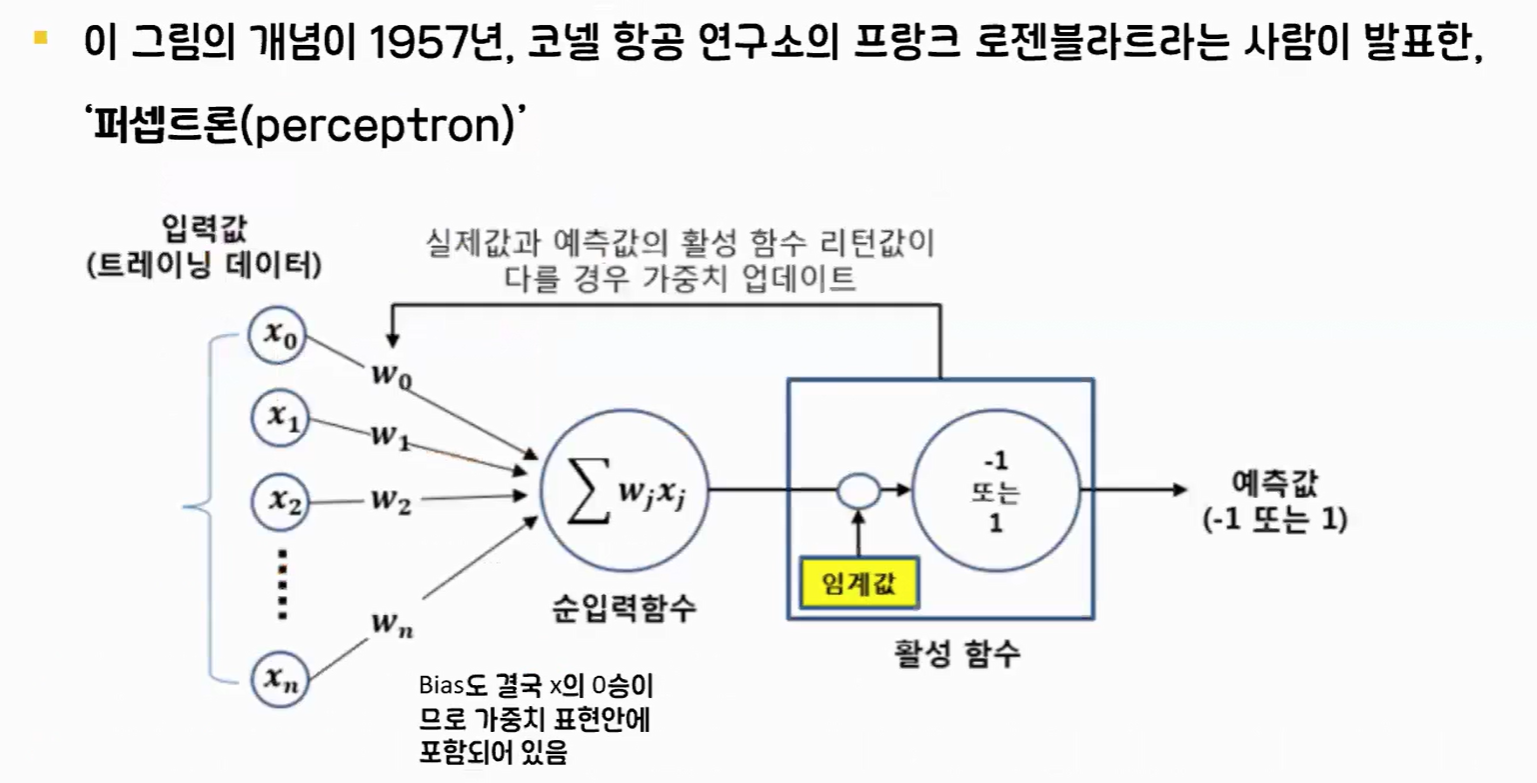

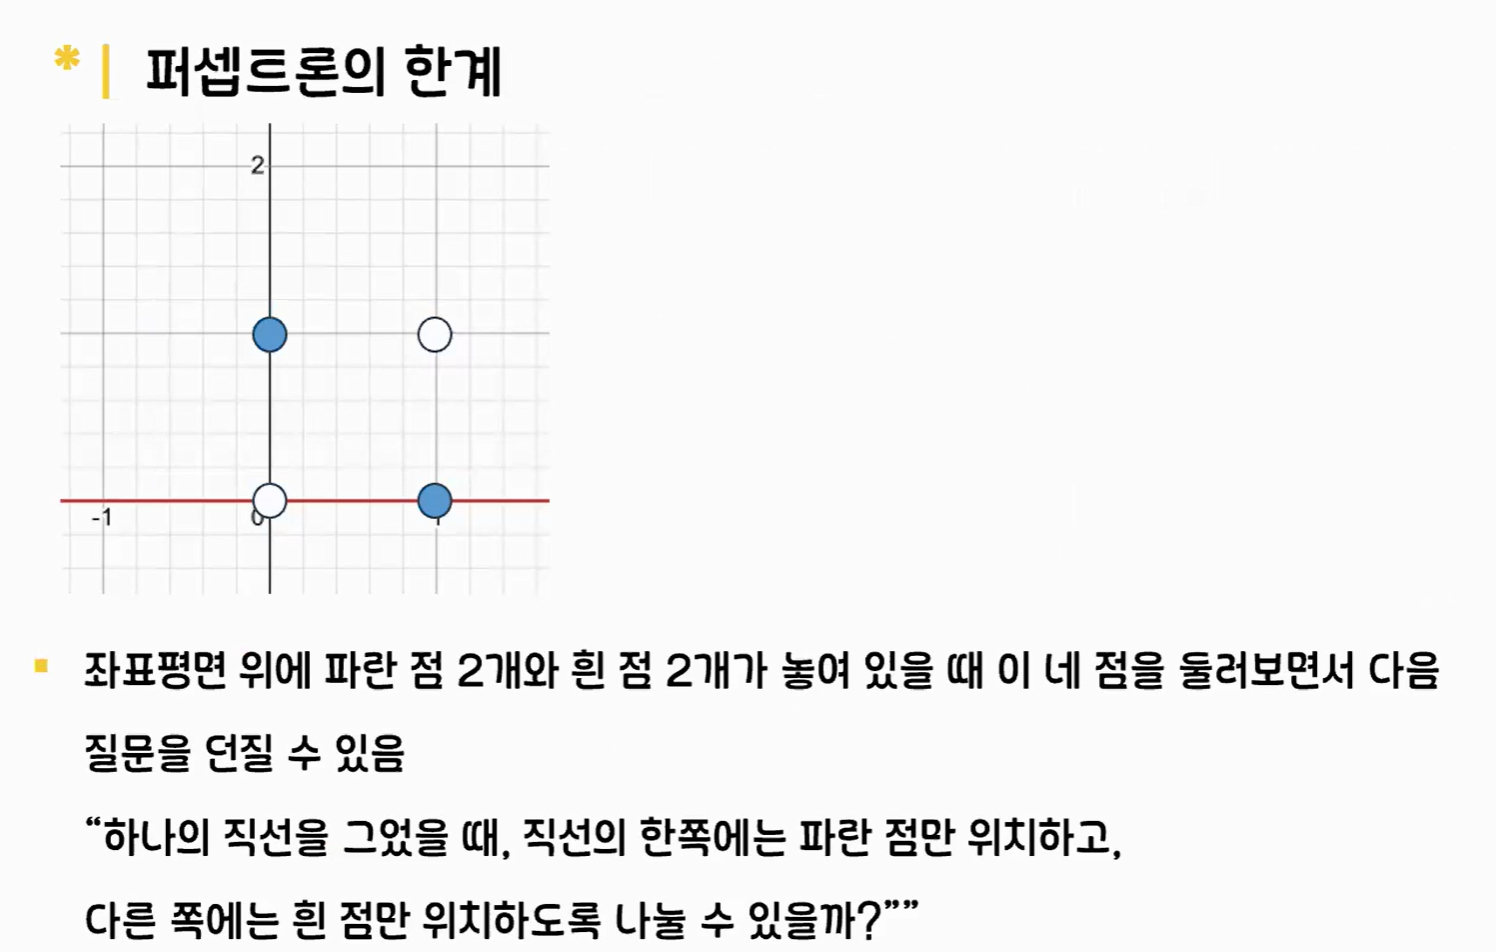

In [ ]:
# XOR : 두 입력 값이 서로 다를 떄만 1을 출력한다.
# 0, 0 -> 0
# 1, 0 -> 1
# 0, 1 -> 1
# 1, 1 -> 0

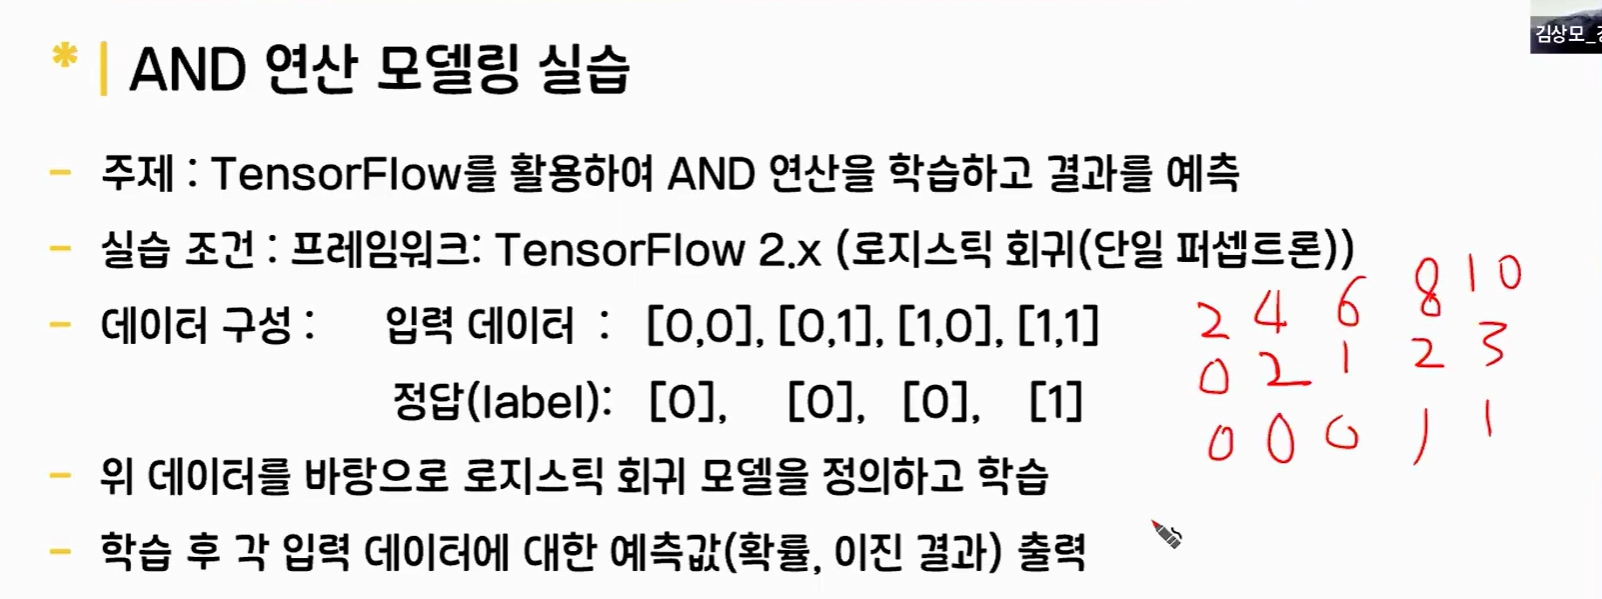

In [ ]:
# x_data(입력) : [[0, 0], [0, 1], [1, 0], [1, 1]] 일 때
# y_data(출력) : [[0], [0], [0], [1]] 인 AND연산

In [5]:
import tensorflow as tf
import numpy as np

# 시드 설정
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

# 1. 데이터 정의
# 공부시간(x1), 학원횟수(x2) 합격여부(y) : 0시간 공부하고 0번 학원나가서 0(불합격), 0시간 공부하고 1번 학원나가서 1(합격)
x_data = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y_data = np.array([[0], [0], [0], [1]], dtype=np.float32)

# 기울기, 절편 정의
W = tf.Variable(tf.random.normal([2, 1], dtype=tf.float32))  # Shape=(2, 1), x1(공부시간), x2(학원횟수) 입력값 2개니까 W1, W2 가중치도 2개
b = tf.Variable(tf.random.normal([1], dtype=tf.float32))

# 가설 함수(시그모이드 함수)
def logistic_predict(X) :
    z = tf.matmul(X, W) + b
    return tf.sigmoid(z) # 브로드캐스팅 (b절편 => [0.5, 0.5, 0.5, 0.5])

# 손실 함수
def costFunc() :
    pred = logistic_predict(x_data)
    cost = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_data, pred))
    return cost

opt = tf.keras.optimizers.SGD(learning_rate=0.1) # 옵티마이저 정의

# 학습 수행
for i in range(2001) :
    with tf.GradientTape() as tape :
        current_cost = costFunc()
    grads = tape.gradient(current_cost, [W, b])
    opt.apply_gradients(zip(grads, [W, b]))

    if i % 200 == 0 :
       print(f"Step : {i} 번째, Loss : {current_cost.numpy():.2f}") 

# 7. 예측 및 출력
print("\n--- 예측 결과 ---")
pred = logistic_predict(x_data).numpy()
pred_binary = (pred > 0.5).astype(int)

for i in range(len(x_data)):
    print(f"입력: {x_data[i]}, 예측(확률): {pred[i][0]:.2f}, 예측(이진): {pred_binary[i][0]}")

# 8. 정확도 출력
accuracy = np.mean(pred_binary == y_data)
print(f"\n정확도(Accuracy): {accuracy:.2f}")

Step : 0 번째, Loss : 1.44
Step : 200 번째, Loss : 0.35
Step : 400 번째, Loss : 0.25
Step : 600 번째, Loss : 0.20
Step : 800 번째, Loss : 0.16
Step : 1000 번째, Loss : 0.14
Step : 1200 번째, Loss : 0.12
Step : 1400 번째, Loss : 0.11
Step : 1600 번째, Loss : 0.10
Step : 1800 번째, Loss : 0.09
Step : 2000 번째, Loss : 0.08

--- 예측 결과 ---
입력: [0. 0.], 예측(확률): 0.00, 예측(이진): 0
입력: [0. 1.], 예측(확률): 0.09, 예측(이진): 0
입력: [1. 0.], 예측(확률): 0.09, 예측(이진): 0
입력: [1. 1.], 예측(확률): 0.87, 예측(이진): 1

정확도(Accuracy): 1.00


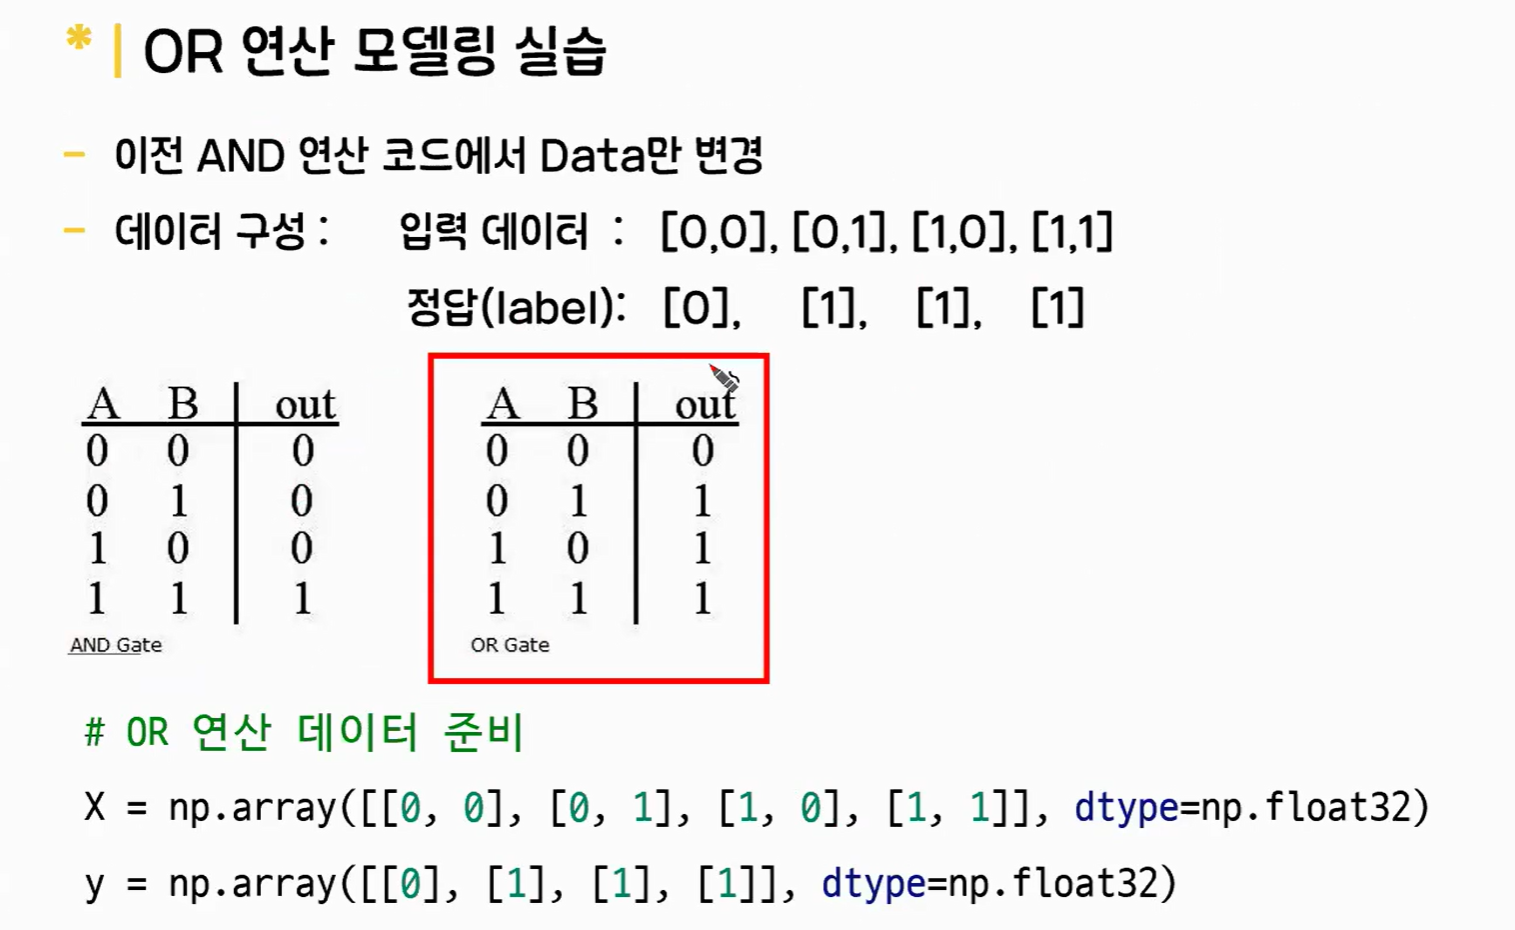

In [ ]:
# x_data(입력) : [[0, 0], [0, 1], [1, 0], [1, 1]] 일 때
# y_data(출력) : [[0], [1], [1], [1]] 인 OR연산

In [6]:
import tensorflow as tf
import numpy as np

# 시드 설정
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

# 1. 데이터 정의
# 공부시간(x1), 학원횟수(x2) 합격여부(y) : 0시간 공부하고 0번 학원나가서 0(불합격), 0시간 공부하고 1번 학원나가서 1(합격)
x_data = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y_data = np.array([[0], [1], [1], [1]], dtype=np.float32) # 여기만 변경!!

# 기울기, 절편 정의
W = tf.Variable(tf.random.normal([2, 1], dtype=tf.float32))  # Shape=(2, 1), x1(공부시간), x2(학원횟수) 입력값 2개니까 W1, W2 가중치도 2개
b = tf.Variable(tf.random.normal([1], dtype=tf.float32))

# 가설 함수(시그모이드 함수)
def logistic_predict(X) :
    z = tf.matmul(X, W) + b
    return tf.sigmoid(z) # 브로드캐스팅 (b절편 => [0.5, 0.5, 0.5, 0.5])

# 손실 함수
def costFunc() :
    pred = logistic_predict(x_data)
    cost = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_data, pred))
    return cost

opt = tf.keras.optimizers.SGD(learning_rate=0.1) # 옵티마이저 정의

# 학습 수행
for i in range(2001) :
    with tf.GradientTape() as tape :
        current_cost = costFunc()
    grads = tape.gradient(current_cost, [W, b])
    opt.apply_gradients(zip(grads, [W, b]))

    if i % 200 == 0 :
       print(f"Step : {i} 번째, Loss : {current_cost.numpy():.2f}") 

# 7. 예측 및 출력
print("\n--- 예측 결과 ---")
pred = logistic_predict(x_data).numpy()
pred_binary = (pred > 0.5).astype(int)

for i in range(len(x_data)):
    print(f"입력: {x_data[i]}, 예측(확률): {pred[i][0]:.2f}, 예측(이진): {pred_binary[i][0]}")

# 8. 정확도 출력
accuracy = np.mean(pred_binary == y_data)
print(f"\n정확도(Accuracy): {accuracy:.2f}")

Step : 0 번째, Loss : 0.42
Step : 200 번째, Loss : 0.24
Step : 400 번째, Loss : 0.17
Step : 600 번째, Loss : 0.13
Step : 800 번째, Loss : 0.10
Step : 1000 번째, Loss : 0.09
Step : 1200 번째, Loss : 0.07
Step : 1400 번째, Loss : 0.06
Step : 1600 번째, Loss : 0.06
Step : 1800 번째, Loss : 0.05
Step : 2000 번째, Loss : 0.05

--- 예측 결과 ---
입력: [0. 0.], 예측(확률): 0.10, 예측(이진): 0
입력: [0. 1.], 예측(확률): 0.96, 예측(이진): 1
입력: [1. 0.], 예측(확률): 0.96, 예측(이진): 1
입력: [1. 1.], 예측(확률): 1.00, 예측(이진): 1

정확도(Accuracy): 1.00


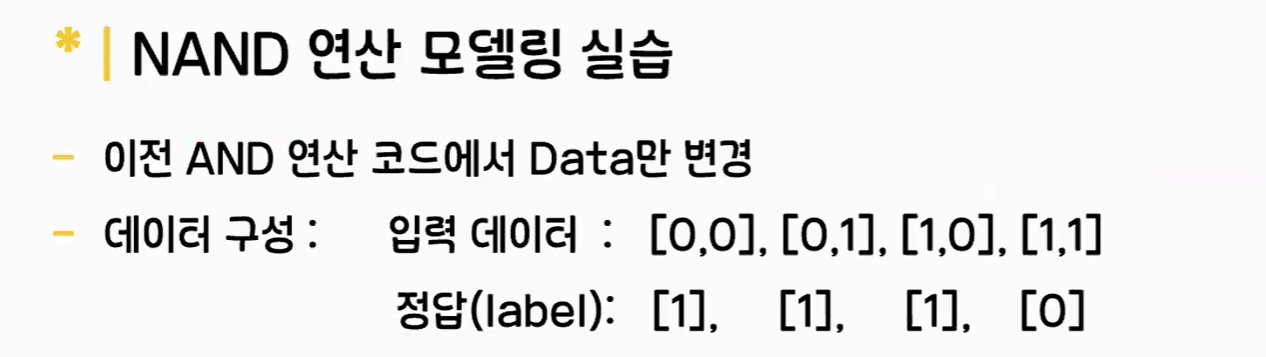

In [ ]:
# x_data(입력) : [[0, 0], [0, 1], [1, 0], [1, 1]] 일 때
# y_data(출력) : [[1], [1], [1], [0]] 인 NAND연산
# AND연사의 반대(N)

In [ ]:
# 코드 동일하므로 생략

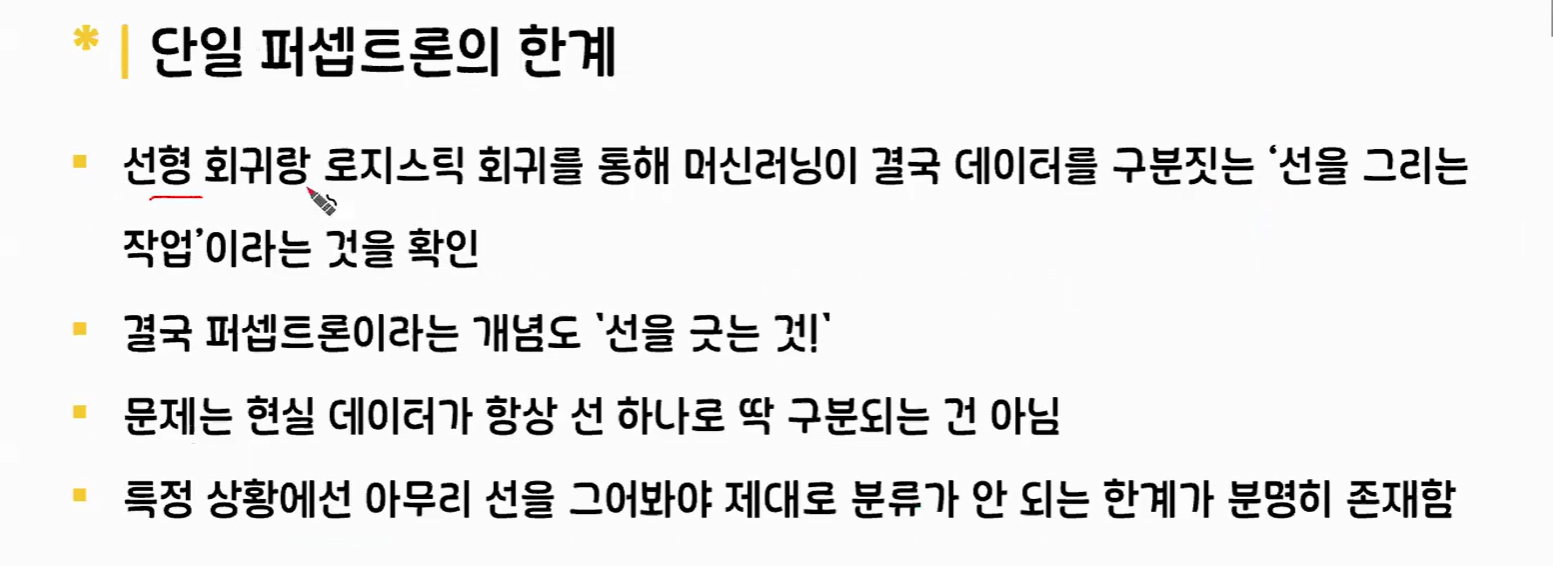

In [ ]:
# x_data(입력) : [[0, 0], [0, 1], [1, 0], [1, 1]] 일 때
# y_data(출력) : [[0], [1], [1], [0]] 인 XOR연산

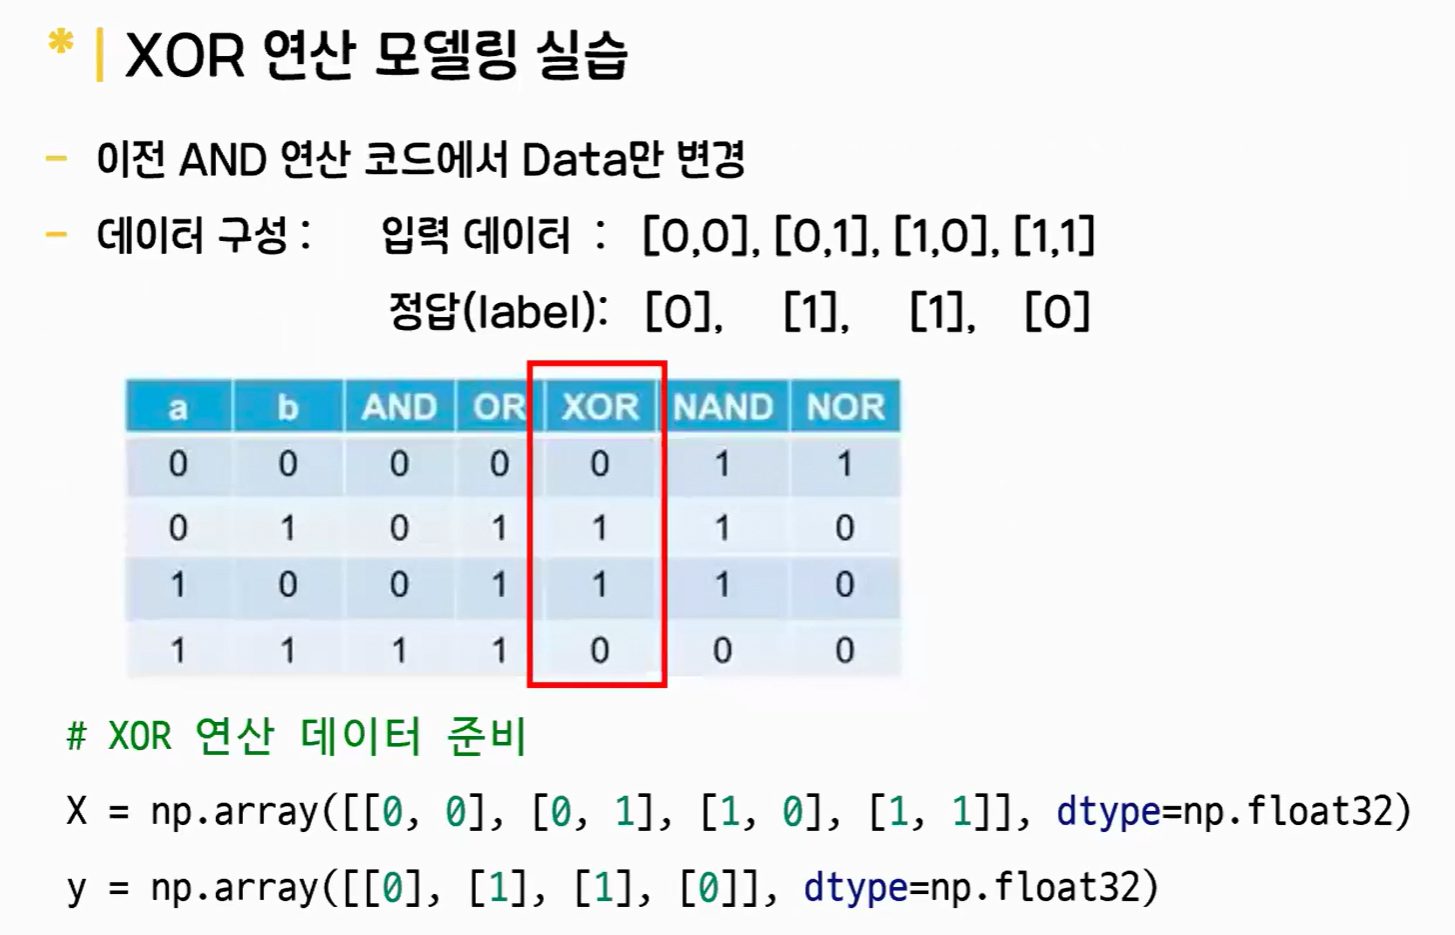

In [ ]:
# 코드 동일하므로 생략
# Accuracy 1.0이 안나온다.(단일 퍼셉트론의 한계!)

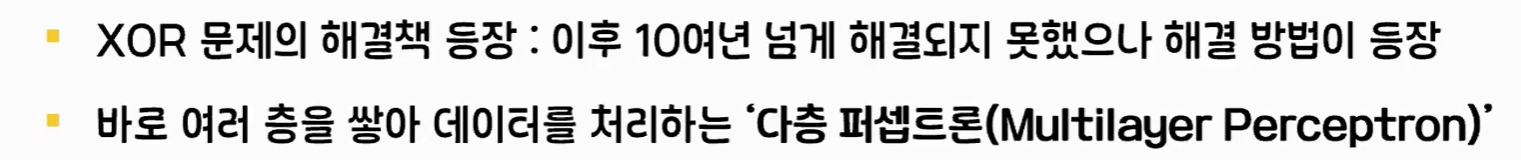

In [ ]:
# 마빈 민스키(Marvin Minsky) 교수의 발표.
# 퍼셉트론즈(1969)
# x1 XOR x2 = NOT(x1 AND x2) AND (x1 OR x2)
# 비선형성 도입
# 히든레이어

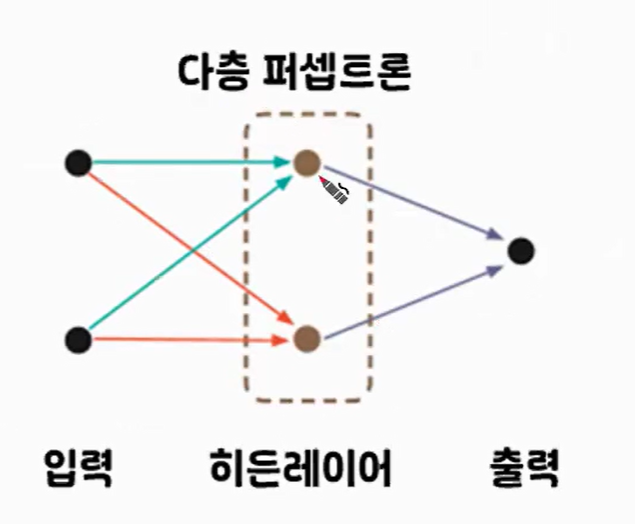

In [ ]:
# n1 = σ(X1 * W11 + X2 * W21 + b1)
# n2 = σ(X1 * W12 + X2 * W22 + b2)
# 다층 퍼셉트론 y_out = σ(n1 * W31 + n2 * W32 + b3)
# 단층 퍼셉트론 y_out = σ(x1 * W1 + x2 * W2 + b)

# 노드의 갯수는 공간이 몇번이냐 꺾이느냐(비선형)
# 히든레이어(층)의 갯수는 선형,로그회귀 함수를 몇번이나 중첩하느냐

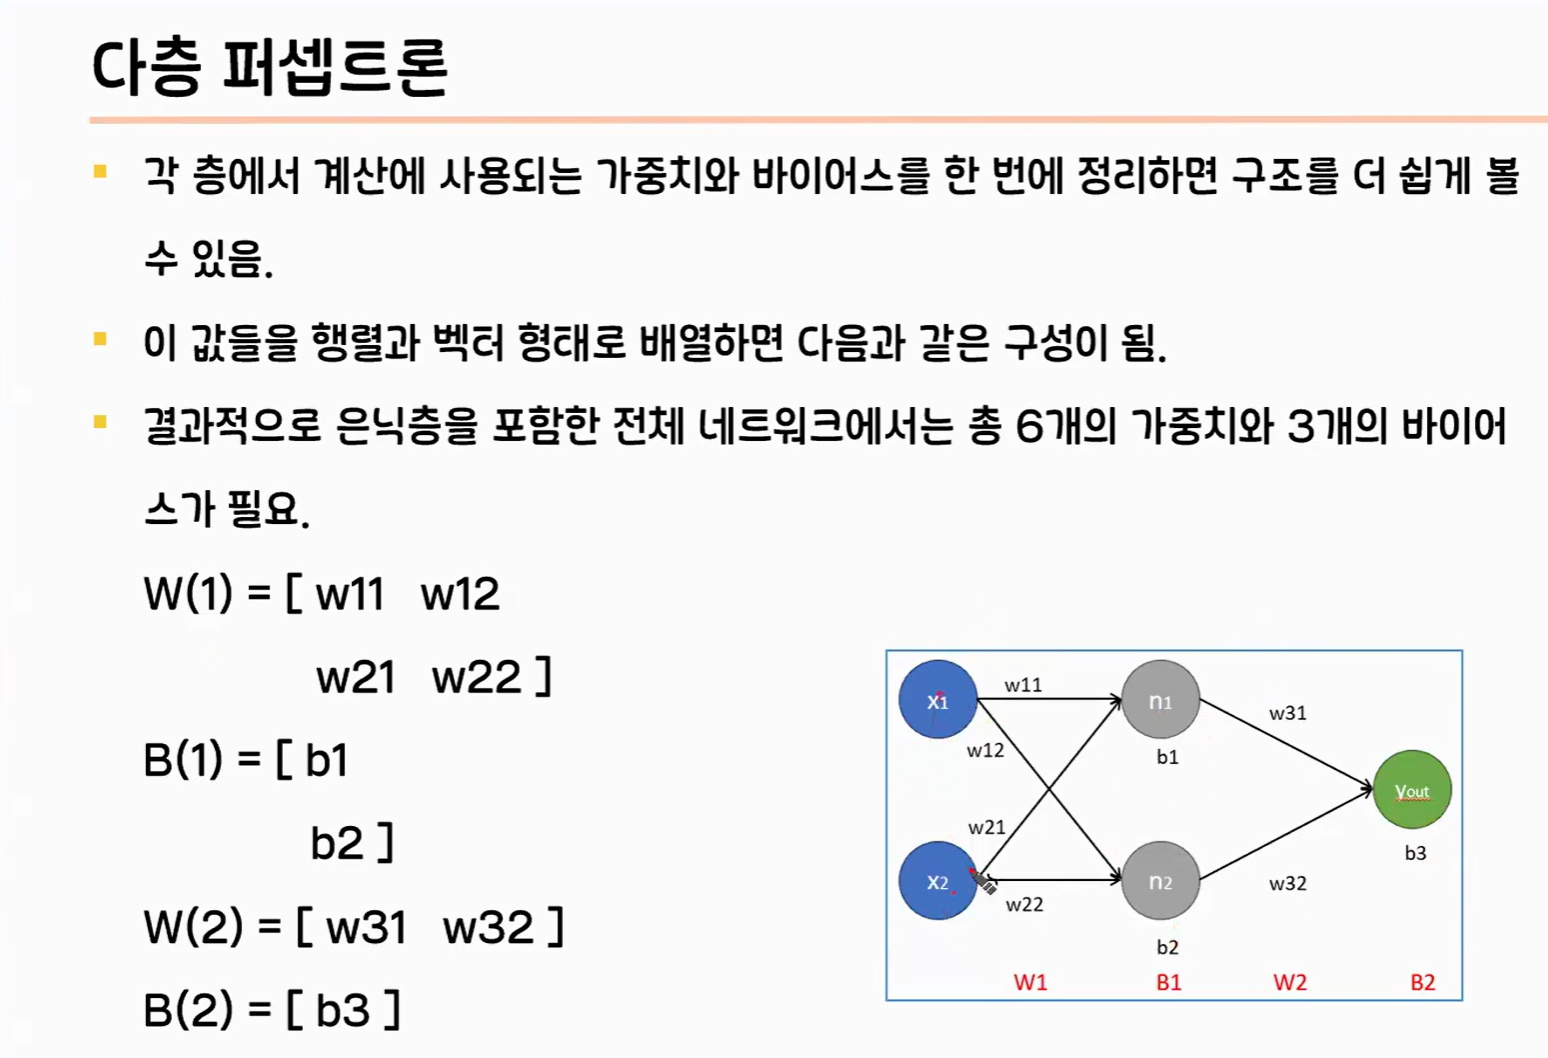

In [ ]:
# 히든레어이의 연산을 우리가 직접 설계할 수 없다.

In [ ]:
# XOR 문제의 해결

In [8]:
import numpy as np
import tensorflow as tf

# XOR연산데이터 준비
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

# 은닉층 가중치(2x2)와 편향(2)정의
W1 = tf.Variable(tf.random.normal([2, 2]))
b1 = tf.Variable(tf.random.normal([2]))

# 출력층 가중치(2x1)과 편향(1)정의
W2 = tf.Variable(tf.random.normal([2, 1]))
b2 = tf.Variable(tf.random.normal([1]))

# 활성화 함수 : 1 / 1+e^-(ax+b)
def sigmoid(x) :
    return 1 / (1 + tf.exp(-x)) 

# 다층 퍼셉트론 정의(은닉층 -> 출력층) : 순방향
def perceptron(x) :
    #은닉층 연산
    hidden = sigmoid(tf.matmul(x, W1) + b1)
    #출력층 연산
    return sigmoid(tf.matmul(hidden, W2) + b2)

# 손실 함수 정의 : -{y * log hypothesis + (1 - y) * log (1 - hypothesis)}
def loss_fn(y_true, y_pred) :
    return tf.reduce_mean(-(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred)))

# optimizer 정의(SGD)
optimizer = tf.keras.optimizers.SGD(learning_rate=0.5)

# 결과를 0 또는 1로 변환하는 함수
def binary_output(x) :
    return int(x.numpy()[0][0] > 0.5)

# Accuracy계산 함수
def accuracy(y_true, y_pred) :
    correct_prediction = tf.equal(tf.cast(y_pred > 0.5, tf.float32), y_true)
    return tf.reduce_mean(tf.cast(correct_prediction, tf.float32))

# 학습 과정 : 역방향(오차역전파)
for epoch in range(2000) :
    with tf.GradientTape() as tape :
         pred = perceptron(X)
         loss = loss_fn(y, pred)
    gradients = tape.gradient(loss, [W1, b1, W2, b2])
    optimizer.apply_gradients(zip(gradients, [W1, b1, W2, b2]))

    #500번 마다 학습과정 출력
    if(epoch + 1) % 500 == 0 :
       W1_val = np.squeeze(W1.numpy())
       b1_val = np.squeeze(b1.numpy())
       W2_val = np.squeeze(W2.numpy())
       b2_val = np.squeeze(b2.numpy())
       print(f"step = {epoch + 1}, cost = {loss.numpy():.4f}")
       print(f"W1 = {W1_val}, b1 = {b1_val}")
       print(f"W2 = {W1_val}, b2 = {b1_val}")
       print("-----------------------------")

# 학습 결과 출력
for input_data in X :
    prediction = perceptron(np.array([input_data], dtype=np.float32))
    print(f"입력 : {input_data.tolist()}, 예측(확률) : {prediction.numpy()[0][0]:.4f}, 예측(이진) : {binary_output(prediction)}")

# 정확도 출력
predictions = perceptron(X)
acc = accuracy(y, predictions)
print(f"정확도 : {acc.numpy():.4f}")

step = 500, cost = 0.1105
W1 = [[ 5.1017513  4.480174 ]
 [-5.008808  -3.9009087]], b1 = [-3.0566943  1.7507929]
W2 = [[ 5.1017513  4.480174 ]
 [-5.008808  -3.9009087]], b2 = [-3.0566943  1.7507929]
-----------------------------
step = 1000, cost = 0.0311
W1 = [[ 5.854717   5.6042156]
 [-5.8397255 -5.203311 ]], b1 = [-3.2791264  2.5229065]
W2 = [[ 5.854717   5.6042156]
 [-5.8397255 -5.203311 ]], b2 = [-3.2791264  2.5229065]
-----------------------------
step = 1500, cost = 0.0175
W1 = [[ 6.162644   6.0398626]
 [-6.1917553 -5.6722608]], b1 = [-3.3913994  2.7814264]
W2 = [[ 6.162644   6.0398626]
 [-6.1917553 -5.6722608]], b2 = [-3.3913994  2.7814264]
-----------------------------
step = 2000, cost = 0.0121
W1 = [[ 6.352421   6.299432 ]
 [-6.4080167 -5.9475   ]], b1 = [-3.4659395  2.92904  ]
W2 = [[ 6.352421   6.299432 ]
 [-6.4080167 -5.9475   ]], b2 = [-3.4659395  2.92904  ]
-----------------------------
입력 : [0.0, 0.0], 예측(확률) : 0.0116, 예측(이진) : 0
입력 : [0.0, 1.0], 예측(확률) : 0.9840, 예측(이진)

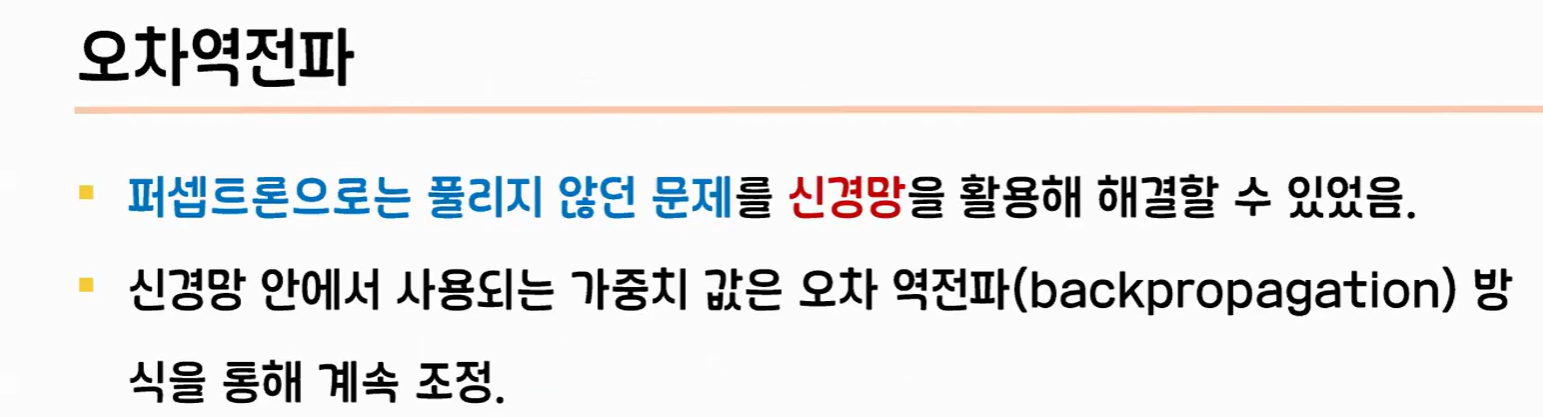

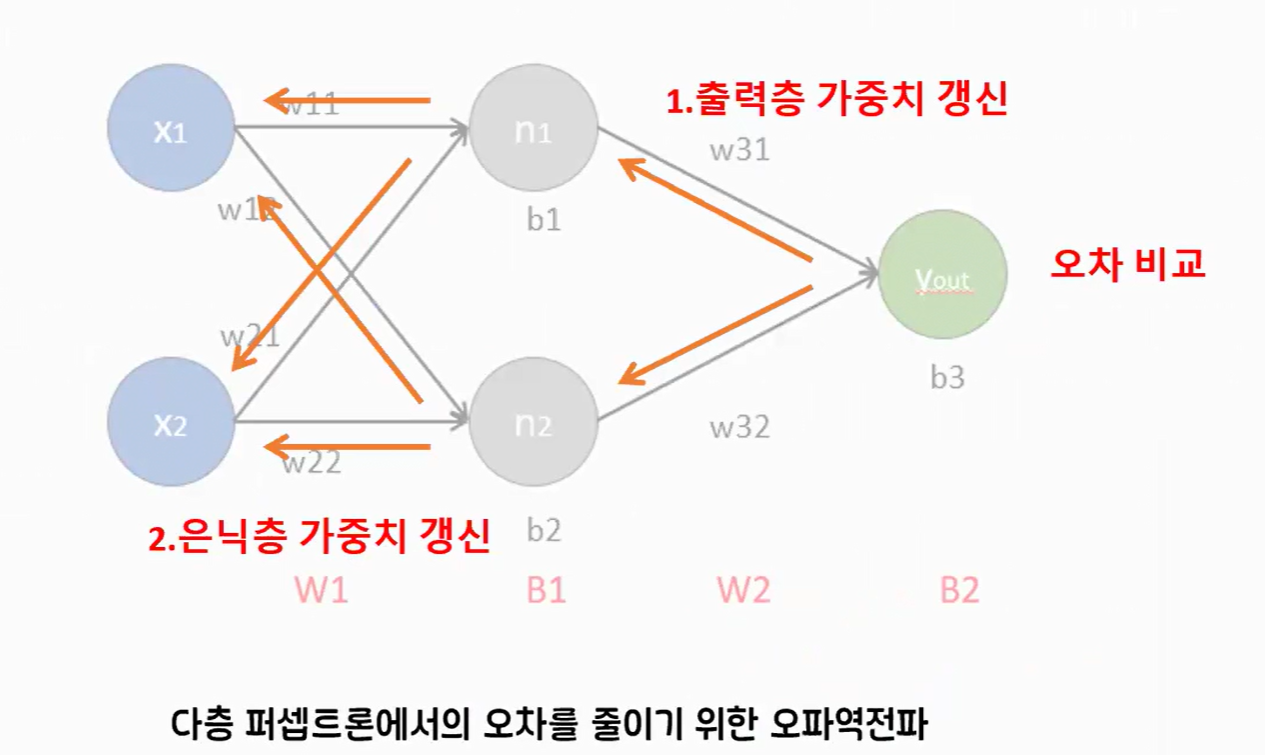